In [ ]:
import os

# Work around CuPy NVRTC CUB reduction compile issues in some CUDA setups.
os.environ.setdefault("CUPY_ACCELERATORS", "")

import numpy as np
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import LabelEncoder

# GPU-only: require RAPIDS + CUDA. Do not fall back to CPU.
import cupy as cp
from cuml import set_global_output_type
from cuml.ensemble import RandomForestClassifier

set_global_output_type("numpy")

print("RAPIDS cuML loaded - GPU-only mode")
print(f"GPU Device: {cp.cuda.Device()}")
print(f"Total GPU Memory: {cp.cuda.Device().mem_info[1] / 1e9:.2f} GB")


# Official split-aligned features (train vs val) from superpixel graphs.
X_train_official = np.load("train_superpixel_graphs.npy").reshape(15701, -1).astype(np.float32)
X_val_official = np.load("val_superpixel_graphs.npy").reshape(3857, -1).astype(np.float32)
y_train_labels = np.load("train_labels.npy")
y_val_labels = np.load("val_labels.npy")

# cuML cannot train on unicode labels, so encode class labels to int IDs.
label_encoder = LabelEncoder()
label_encoder.fit(np.concatenate([y_train_labels, y_val_labels]))
y_train_official = label_encoder.transform(y_train_labels).astype(np.int32)
y_val_official = label_encoder.transform(y_val_labels).astype(np.int32)

print("\nOfficial split shapes:")
print("X_train:", X_train_official.shape, "y_train:", y_train_official.shape)
print("X_val  :", X_val_official.shape, "y_val  :", y_val_official.shape)

# Baseline on official split (GPU)
baseline_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=16,
    max_features=1.0,
    random_state=42,
)
baseline_rf.fit(X_train_official, y_train_official)
baseline_pred = baseline_rf.predict(X_val_official).astype(np.int32)

baseline_acc = accuracy_score(y_val_official, baseline_pred)
baseline_macro_f1 = f1_score(y_val_official, baseline_pred, average="macro")

print("\n[Baseline RF on official split - GPU]")
print(f"Accuracy: {baseline_acc:.4f}")
print(f"Macro-F1: {baseline_macro_f1:.4f}")

# Tuned RF on official split (GPU-compatible params only)
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [16, 40],
    "max_features": [1.0, 0.3],
    "min_samples_leaf": [1, 2],
}

best_model = None
best_params = None
best_macro_f1 = -1.0

for params in ParameterGrid(param_grid):
    rf = RandomForestClassifier(
        random_state=42,
        **params,
    )
    rf.fit(X_train_official, y_train_official)
    pred = rf.predict(X_val_official).astype(np.int32)

    macro_f1 = f1_score(y_val_official, pred, average="macro")

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_model = rf
        best_params = params
    print(f"Tested params: {params} -> Macro-F1: {macro_f1:.4f}")

best_pred = best_model.predict(X_val_official).astype(np.int32)
best_acc = accuracy_score(y_val_official, best_pred)

# Decode numeric class IDs back to original labels for readable report.
best_pred_labels = label_encoder.inverse_transform(best_pred)

print("\n[Tuned RF on official split - GPU]")
print("Best params:", best_params)
print(f"Accuracy: {best_acc:.4f}")
print(f"Macro-F1: {best_macro_f1:.4f}")
print("\nClassification report (tuned model):")
print(classification_report(y_val_labels, best_pred_labels))

print("\nComparison summary:")
print(f"Baseline  -> Accuracy: {baseline_acc:.4f}, Macro-F1: {baseline_macro_f1:.4f}")
print(f"Tuned RF  -> Accuracy: {best_acc:.4f}, Macro-F1: {best_macro_f1:.4f}")


RAPIDS cuML loaded - GPU-only mode
GPU Device: <CUDA Device 0>
Total GPU Memory: 12.49 GB

Official split shapes:
X_train: (15701, 3800) y_train: (15701,)
X_val  : (3857, 3800) y_val  : (3857,)


In [ ]:
%pip install scikit-learn

Loaded metadata rows: 24450
Split counts: {'train': 15702, 'test': 4891, 'val': 3857}
Deep feature root: FGVD_Graph_Handover/deep_features/multilevel

Raw feature shape   : (4096, 64)
Reduced feature dim : 64
Total rows          : 24450
Est. RAM for reduced matrix : ~0.01 GB


[L1 | tw_vs_all]  building features …
  train: kept=15702 missing=0
  val: kept=3850 missing=7
  test: kept=4890 missing=1
  Shapes  : train=(15702, 64)  val=(3850, 64)  test=(4890, 64)
  Classes : [np.str_('other'), np.str_('two_wheeler')]
  Val  -> acc=0.9686  macro_f1=0.9667
  Test -> acc=0.9616  macro_f1=0.9600
              precision    recall  f1-score   support

       other     0.9578    0.9783    0.9679      2897
 two_wheeler     0.9674    0.9373    0.9521      1993

    accuracy                         0.9616      4890
   macro avg     0.9626    0.9578    0.9600      4890
weighted avg     0.9617    0.9616    0.9615      4890


[L1 | thw_vs_all]  building features …
  train: kept=15702 missing=0
  val: k

/home/user/anaconda3/envs/fgvd/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/anaconda3/envs/fgvd/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/anaconda3/envs/fgvd/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

  train: kept=15702 missing=0
  val: kept=3850 missing=7
  test: kept=4890 missing=1
  Shapes  : train=(15702, 64)  val=(3850, 64)  test=(4890, 64)
  Classes : [np.str_('other'), np.str_('two_wheeler')]
  Val  -> acc=0.9686  macro_f1=0.9667
  Test -> acc=0.9616  macro_f1=0.9600
              precision    recall  f1-score   support

       other     0.9578    0.9783    0.9679      2897
 two_wheeler     0.9674    0.9373    0.9521      1993

    accuracy                         0.9616      4890
   macro avg     0.9626    0.9578    0.9600      4890
weighted avg     0.9617    0.9616    0.9615      4890


[L3 | thw_vs_all]  building features …
  train: kept=15702 missing=0
  val: kept=3850 missing=7
  test: kept=4890 missing=1
  Shapes  : train=(15702, 64)  val=(3850, 64)  test=(4890, 64)
  Classes : [np.str_('other'), np.str_('three_wheeler')]
  Val  -> acc=0.9618  macro_f1=0.9235
  Test -> acc=0.9616  macro_f1=0.9199
               precision    recall  f1-score   support

        other    

/home/user/anaconda3/envs/fgvd/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/anaconda3/envs/fgvd/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/anaconda3/envs/fgvd/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}


Level  Case              Test Acc   Test F1  Classes
L1     tw_vs_all           96.16%     96.00%        2
L1     thw_vs_all          96.16%     91.99%        2
L1     tw_thw_vs_all       94.19%     94.12%        2
L1     all                 84.19%     72.66%        7
L2     tw_vs_all           96.16%     96.00%        2
L2     thw_vs_all          96.16%     91.99%        2
L2     tw_thw_vs_all       94.19%     94.12%        2
L2     all                 51.96%     23.02%       39
L3     tw_vs_all           96.16%     96.00%        2
L3     thw_vs_all          96.16%     91.99%        2
L3     tw_thw_vs_all       94.19%     94.12%        2
L3     all                 44.17%     15.44%      200


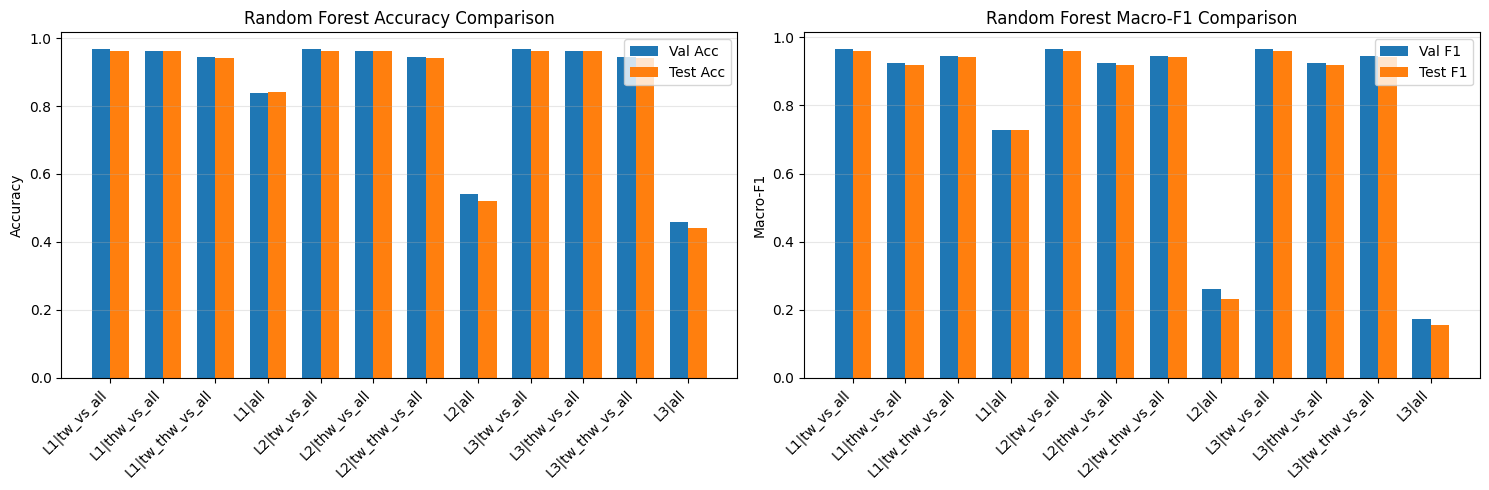

Saved plot: plots/rf/rf_comparison.png


In [2]:
# Random Forest on deep features (FGVD_Graph_Handover metadata-aligned)
# Uses deep node features from FGVD_Graph_Handover/deep_features/multilevel
# Updated: pool the 4096x64 deep feature tensor down to 64 dims per sample
# to avoid flattening 262144 values per vehicle.

import gc
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

ROOT = Path("FGVD_Graph_Handover")
META_PATH = ROOT / "metadata.csv"
DEEP_SUBDIR = "multilevel"
DEEP_ROOT = ROOT / "deep_features" / DEEP_SUBDIR

metadata = pd.read_csv(META_PATH)
for c in ["vehicle_id", "split", "L1", "L2", "L3"]:
    metadata[c] = metadata[c].astype(str).str.strip()

print("Loaded metadata rows:", len(metadata))
print("Split counts:", metadata["split"].value_counts().to_dict())
print("Deep feature root:", DEEP_ROOT)

# ── Diagnostic: estimate memory before running ────────────────────────────────
_sample_row = metadata.iloc[0]
_sample_path = DEEP_ROOT / _sample_row["split"] / f"{_sample_row['vehicle_id']}.npy"
if _sample_path.exists():
    _feat = np.load(_sample_path, mmap_mode="r")
    _reduced_feat = _feat.mean(axis=0, dtype=np.float32)
    feat_dim = int(_reduced_feat.size)
    total_rows = len(metadata)
    est_gb = feat_dim * total_rows * 4 / 1e9
    print(f"\nRaw feature shape   : {_feat.shape}")
    print(f"Reduced feature dim : {feat_dim}")
    print(f"Total rows          : {total_rows}")
    print(f"Est. RAM for reduced matrix : ~{est_gb:.2f} GB")
    print()
    del _feat, _reduced_feat
else:
    print(f"Warning: sample file not found at {_sample_path}")
# ─────────────────────────────────────────────────────────────────────────────

CASES = ["tw_vs_all", "thw_vs_all", "tw_thw_vs_all", "all"]


def coarse_type(v):
    return str(v).strip().lower().replace("-", "").replace(" ", "")


def case_map(labels, case_name):
    labels = np.asarray([str(x) for x in labels])

    if case_name == "all":
        return labels

    tw_set = {"motorcycle", "scooter"}
    thw_set = {"autorickshaw", "auto", "three_wheeler", "threewheeler"}

    out = []
    for l in labels:
        lc = coarse_type(l)
        if case_name == "tw_vs_all":
            out.append("two_wheeler" if lc in tw_set else "other")
        elif case_name == "thw_vs_all":
            out.append("three_wheeler" if lc in thw_set else "other")
        elif case_name == "tw_thw_vs_all":
            out.append("two_or_three_wheeler" if (lc in tw_set or lc in thw_set) else "other")
        else:
            raise ValueError(f"Unknown case: {case_name}")
    return np.asarray(out)


def deep_feature_path(vehicle_id, split):
    return DEEP_ROOT / split / f"{vehicle_id}.npy"


def reduce_deep_feature(arr):
    """Pool the 4096 node embeddings to a single 64-D vector per sample."""
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D feature matrix, got shape {arr.shape}")
    return arr.mean(axis=0, dtype=np.float32)


def load_feature_row(vehicle_id, split):
    """Load a single .npy file as a memmap view and reduce it to 64 dims."""
    p = deep_feature_path(vehicle_id, split)
    arr = np.load(p, mmap_mode="r")
    return reduce_deep_feature(arr)


def build_split_xy(level, case_name):
    train_df = metadata[metadata["split"] == "train"].reset_index(drop=True)
    val_df = metadata[metadata["split"] == "val"].reset_index(drop=True)
    test_df = metadata[metadata["split"] == "test"].reset_index(drop=True)

    def build(df, split_name):
        keep_indices = []
        rows = []
        missing = 0

        for i, row in enumerate(df.itertuples(index=False)):
            p = deep_feature_path(row.vehicle_id, row.split)
            if p.exists():
                rows.append(load_feature_row(row.vehicle_id, row.split))
                keep_indices.append(i)
            else:
                missing += 1

        if not rows:
            raise RuntimeError(f"No deep feature files found for split={split_name}")

        df_kept = df.iloc[keep_indices].reset_index(drop=True)
        X = np.stack(rows, axis=0).astype(np.float32)
        del rows
        gc.collect()

        y_raw = df_kept[level].astype(str).values
        if case_name != "all":
            coarse = df_kept["L1"].astype(str).values
            y_raw = case_map(coarse, case_name)

        print(f"  {split_name}: kept={len(df_kept)} missing={missing}")
        return X, y_raw

    X_train, y_train_raw = build(train_df, "train")
    X_val, y_val_raw = build(val_df, "val")
    X_test, y_test_raw = build(test_df, "test")

    le = LabelEncoder()
    le.fit(np.concatenate([y_train_raw, y_val_raw, y_test_raw]))

    y_train = le.transform(y_train_raw).astype(np.int32)
    y_val = le.transform(y_val_raw).astype(np.int32)
    y_test = le.transform(y_test_raw).astype(np.int32)

    return X_train, y_train, X_val, y_val, X_test, y_test, y_test_raw, le


def run_rf(level, case_name):
    print(f"\n[{level} | {case_name}]  building features …")
    X_train, y_train, X_val, y_val, X_test, y_test, y_test_raw, le = build_split_xy(level, case_name)

    print(f"  Shapes  : train={X_train.shape}  val={X_val.shape}  test={X_test.shape}")
    print(f"  Classes : {list(le.classes_)}")

    rf_params = {
        "n_estimators": 100,
        "max_depth": 20,
        "max_features": "sqrt",
        "min_samples_leaf": 2,
        "random_state": 42,
        "n_jobs": 2,
    }

    rf = RandomForestClassifier(**rf_params)
    rf.fit(X_train, y_train)

    val_pred = rf.predict(X_val).astype(np.int32)
    test_pred = rf.predict(X_test).astype(np.int32)

    val_acc = accuracy_score(y_val, val_pred)
    val_f1 = f1_score(y_val, val_pred, average="macro")
    test_acc = accuracy_score(y_test, test_pred)
    test_f1 = f1_score(y_test, test_pred, average="macro")

    test_pred_labels = le.inverse_transform(test_pred)

    print(f"  Val  -> acc={val_acc:.4f}  macro_f1={val_f1:.4f}")
    print(f"  Test -> acc={test_acc:.4f}  macro_f1={test_f1:.4f}")
    print(classification_report(y_test_raw, test_pred_labels, digits=4))

    result = {
        "level": level,
        "case": case_name,
        "val_acc": float(val_acc),
        "val_f1": float(val_f1),
        "test_acc": float(test_acc),
        "test_f1": float(test_f1),
        "num_classes": int(len(le.classes_)),
    }

    ckpt_dir = Path("checkpoints/rf") / f"{level}_{case_name}"
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump({
        "level": level,
        "case": case_name,
        "model": rf,
        "label_encoder": le,
        "result": result,
        "params": rf_params,
    }, ckpt_dir / "best_model.joblib")
    joblib.dump(result, ckpt_dir / "metrics.joblib")

    del X_train, X_val, X_test, rf
    gc.collect()

    return result


results = []
for level in ["L1", "L2", "L3"]:
    for case_name in CASES:
        try:
            results.append(run_rf(level, case_name))
        except Exception as exc:
            print(f"FAILED [{level} | {case_name}]: {exc}")

print("\n" + "=" * 65)
print(f"{'Level':<6} {'Case':<16} {'Test Acc':>9} {'Test F1':>9} {'Classes':>8}")
print("=" * 65)
for r in results:
    print(
        f"{r['level']:<6} {r['case']:<16} "
        f"{r['test_acc']*100:8.2f}%  {r['test_f1']*100:8.2f}%  {r['num_classes']:>7}"
    )

plots_dir = Path("plots/rf")
plots_dir.mkdir(parents=True, exist_ok=True)

if results:
    labels = [f"{r['level']}|{r['case']}" for r in results]
    val_accs = [r['val_acc'] for r in results]
    test_accs = [r['test_acc'] for r in results]
    val_f1s = [r['val_f1'] for r in results]
    test_f1s = [r['test_f1'] for r in results]

    x = np.arange(len(labels))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].bar(x - width / 2, val_accs, width, label="Val Acc")
    axes[0].bar(x + width / 2, test_accs, width, label="Test Acc")
    axes[0].set_title("Random Forest Accuracy Comparison")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=45, ha="right")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].bar(x - width / 2, val_f1s, width, label="Val F1")
    axes[1].bar(x + width / 2, test_f1s, width, label="Test F1")
    axes[1].set_title("Random Forest Macro-F1 Comparison")
    axes[1].set_ylabel("Macro-F1")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=45, ha="right")
    axes[1].legend()
    axes[1].grid(axis="y", alpha=0.3)

    fig.tight_layout()
    out_plot = plots_dir / "rf_comparison.png"
    fig.savefig(out_plot, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plot: {out_plot}")